# Import Required Libraries

In [1]:
import sys
sys.path.append("../braindecode-1.2.0")  # Add the path to the parent folder of braindecode

from braindecode.models.atcnet import ATCNet
from braindecode.classifier import EEGClassifier

In [2]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sklearn packages
from sklearn.preprocessing import (StandardScaler, 
                                    MinMaxScaler)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, train_test_split

from sklearn.metrics import (accuracy_score, 
                            classification_report, 
                            confusion_matrix, 
                            ConfusionMatrixDisplay)


# MNE Packages
import mne
from mne.datasets.sleep_physionet.age import fetch_data
mne.utils.set_config('MNE_USE_CUDA', 'true')



import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch.optim as optim
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from braindecode import EEGClassifier
from skorch.callbacks import LRScheduler

In [3]:
class EEGEpochExtractor:
    def __init__(self, data_dir):
        """
        Initialize the extractor with the directory containing EDF files.
        """
        self.data_dir = data_dir
        self.all_epochs = []

    # --- Trail classification ---
    @staticmethod
    def trail_classification(trail_num: int) -> str:
        if trail_num in [4, 6, 8, 10, 12, 14]:
            return "imaginary"
        elif trail_num in [1, 2]:
            return "baseline"
        else:
            return "motor"

    # --- Event type classification ---
    @staticmethod
    def event_type_classification(trail_num: int):
        if trail_num in [1, 2]:
            return ("rest", "NA", "NA")
        elif trail_num in [3, 4, 7, 8, 11, 12]:
            return ("rest", "left_fist", "right_fist")
        elif trail_num in [5, 6, 9, 10, 13, 14]:
            return ("rest", "both_fist", "both_feet")

    # --- Metadata extraction ---
    def extract_metadata(self) -> pd.DataFrame:
        metadata = []

        for subj in sorted(os.listdir(self.data_dir)):
            subj_path = os.path.join(self.data_dir, subj)
            if not os.path.isdir(subj_path):
                continue

            for file in sorted(os.listdir(subj_path)):
                if file.endswith(".edf") and not file.endswith(".edf.event"):
                    match = re.search(r"R(\d{2})\.edf$", file)
                    if match:
                        trial_num = int(match.group(1))
                        trail_type = self.trail_classification(trial_num)
                        event_type = self.event_type_classification(trial_num)

                        edf_file = os.path.join(subj_path, file)
                        event_file = edf_file + ".event" if os.path.exists(edf_file + ".event") else None

                        metadata.append({
                            "subject": subj,
                            "trial": trial_num,
                            "trail_type": trail_type,
                            "edf_file": edf_file,
                            "event_file": event_file,
                            "T0": event_type[0],
                            "T1": event_type[1],
                            "T2": event_type[2],
                        })

        self.metadata_df = pd.DataFrame(metadata)
        return self.metadata_df


    def process_file(self, file_path, event_id_mapping):
        """
        Process a single EDF file and return epochs.
        """
        print(f"Processing: {file_path}")
        raw_edf = mne.io.read_raw_edf(file_path, preload=True)
        annotations_edf = mne.read_annotations(file_path)

        # Update annotation descriptions
        new_descriptions = [
            event_id_mapping.get(desc, desc) for desc in annotations_edf.description
        ]
        annotations_edf.description = new_descriptions
        
        # Set updated annotations
        raw_edf.set_annotations(annotations_edf)
        
        # Convert annotations to events
        events, event_id = mne.events_from_annotations(raw_edf)
        
        
        epochs = mne.Epochs(
            raw=raw_edf,
            events=events,
            event_id= event_id,
            reject = None,
            flat = None, 
            reject_by_annotation= False, 
            baseline=None,
            preload=True
        )
        return epochs

    def process_all(self):
        """
        Process all EDF files in the directory and store their epochs.
        """
        metadata_info = self.extract_metadata() # Metadata Information
        self.all_epochs = []  # reset list
        for filename in metadata_info["edf_file"].tolist():
            if filename.endswith(".edf"):
                event_id_mapping = {"T0": metadata_info[(metadata_info["edf_file"]==filename)]["T0"].values[0], 
                                    "T1": metadata_info[(metadata_info["edf_file"]==filename)]["T1"].values[0], 
                                    "T2": metadata_info[(metadata_info["edf_file"]==filename)]["T2"].values[0]}
                print(event_id_mapping)
                epochs = self.process_file(file_path=filename, event_id_mapping= event_id_mapping)
                self.all_epochs.append(epochs)
        
        print(f"\nTotal EDF files processed: {len(self.all_epochs)}")
        return self.all_epochs


In [17]:
extractor = EEGEpochExtractor(data_dir= "../data/Original/")
all_epochs = extractor.process_all()

{'T0': 'rest', 'T1': 'NA', 'T2': 'NA'}
Processing: ../data/Original/S001/S001R01.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Used Annotations descriptions: [np.str_('rest')]
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'NA', 'T2': 'NA'}
Processing: ../data/Original/S001/S001R02.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_25888/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_25888/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


1 bad epochs dropped
{'T0': 'rest', 'T1': 'left_fist', 'T2': 'right_fist'}
Processing: ../data/Original/S001/S001R08.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S001/S001R09.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R09.edf...

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_25888/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_25888/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'left_fist', 'T2': 'right_fist'}
Processing: ../data/Original/S002/S002R08.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S002/S002R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S002/S002R09.edf
Extracting EDF parameters from /Us

...

Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S107/S107R09.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S107/S107R09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dro

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_25888/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_25888/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


1 bad epochs dropped
{'T0': 'rest', 'T1': 'left_fist', 'T2': 'right_fist'}
Processing: ../data/Original/S108/S108R08.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S108/S108R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S108/S108R09.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S108/S108R09.edf...

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_25888/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_25888/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'left_fist', 'T2': 'right_fist'}
Processing: ../data/Original/S109/S109R08.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S109/S109R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S109/S109R09.edf
Extracting EDF parameters from /Us

# Extracting Data - X, Y

In [25]:
X, y, groups = [], [], []

for group_id, epochs in enumerate(all_epochs):
    try:
        print(f"Processing participant #{group_id}")

        # Skip empty or invalid epochs
        if len(epochs) == 0:
            print(f"Skipping participant #{group_id}: empty epochs")
            continue

        # Extract data
        epochs = epochs.filter(l_freq = 0.5, h_freq = 30.0, method = 'iir')
        X_epoch = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
        y_epoch_event_mapping = epochs.event_id
        y_epoch = epochs.events[:, 2]  # event ids

        # Map event codes to labels (string form)
        y_epoch = np.array(y_epoch, dtype=object)
        for key, value in y_epoch_event_mapping.items():
            y_epoch[y_epoch == value] = str(key)

        # Add group info
        group_epoch = [group_id] * len(y_epoch)

        # Append
        X.append(X_epoch)
        y.extend(y_epoch)
        groups.extend(group_epoch)

    except Exception as e:
        print(f"Error processing participant #{group_id}: {e}")
        continue

# --- Align time dimension before concatenation ---
if len(X) == 0:
    X = np.empty((0, 64, 113))  # fallback shape
else:
    # Find min time dimension
    min_time = min(x.shape[2] for x in X)
    print(f"Aligning all epochs to {min_time} time samples")

    # Truncate each to same time length
    X = [x[:, :, :min_time] for x in X]

    # Safe concatenation
    X = np.concatenate(X, axis=0)

y = np.array(y, dtype=object)
groups = np.array(groups)

print("Final shapes:")
print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)


Processing participant #0
Skipping participant #0: empty epochs
Processing participant #1
Skipping participant #1: empty epochs
Processing participant #2
Setting up band-pass filter from 0.5 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.50, 30.00 Hz: -6.02, -6.02 dB

Processing participant #3
Setting up band-pass filter from 0.5 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.50, 30.00 Hz: -6.02, -6.02 dB

Processing participant #4
Setting up band-pass filter from 0.5 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.50, 30.00

In [26]:
Y_CAT_MAPPING = {"rest" : 0,
                "both_feet" : 1, 
                "both_fist" : 2, 
                "left_fist" : 3, 
                "right_fist" : 4}

for key, value in Y_CAT_MAPPING.items():
        y[y == key] = value

In [27]:
X = X[(y != 0)] # Excluding label "rest" instances
y = y[(y != 0)]

# Building Model Architecture - Using Braindecode

In [30]:
# -----------------------------
# 1. Device configuration
# -----------------------------
def get_device():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("✅ Using Apple MPS device.")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("✅ Using CUDA device.")
    else:
        device = torch.device("cpu")
        print("⚠️ Using CPU.")
    return device


# -----------------------------
# 2. Data preprocessing
# -----------------------------
def prepare_data(X, y, test_size=0.2, val_size=0.1):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y_encoded, dtype=torch.long)

    # Split train/test first
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_tensor, y_tensor, test_size=test_size, random_state=42, stratify=y_encoded
    )

    # Split remaining into validation and test
    val_ratio = val_size / (1 - test_size)
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp, test_size=1 - val_ratio, random_state=42, stratify=y_temp
    )

    train_ds = TensorDataset(X_train, y_train)
    valid_ds = TensorDataset(X_valid, y_valid)
    test_ds = TensorDataset(X_test, y_test)

    print(f"Train set: {len(train_ds)}, Valid set: {len(valid_ds)}, Test set: {len(test_ds)}")
    return train_ds, valid_ds, test_ds, len(le.classes_)


# -----------------------------
# 3. Model setup
# -----------------------------
def create_model(n_chans, n_outputs, n_times, sfreq, device):
    model = ATCNet(
        n_chans=n_chans,
        n_outputs=n_outputs,
        n_times = n_times,
        sfreq= sfreq,
        conv_block_n_filters=16,
        conv_block_kernel_length_1=64,
        conv_block_kernel_length_2=16,
        conv_block_pool_size_1=8,
        conv_block_pool_size_2=7,
        conv_block_depth_mult=2,
        conv_block_dropout=0.3,
        n_windows=5,
        att_head_dim=8,
        att_num_heads=2,
        tcn_depth=2,
        tcn_kernel_size=4,
        tcn_activation=torch.nn.ELU,
        concat=False,
        max_norm_const=0.25
    )
    model.to(device)
    return model


# -----------------------------
# 4. Training setup
# -----------------------------
def train_model(model, train_ds, valid_ds, num_classes, device, n_epochs=10, batch_size=16):
    lr = 0.0625 * 0.01
    weight_decay = 0

    clf = EEGClassifier(
        model,
        criterion=nn.CrossEntropyLoss(),
        optimizer=torch.optim.AdamW,
        optimizer__lr=lr,
        optimizer__weight_decay=weight_decay,
        batch_size=batch_size,
        train_split=None,  # We'll pass valid_ds manually
        callbacks=[
            "accuracy",
            ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
        ],
        device=device,
        classes=list(range(num_classes)),
        max_epochs=n_epochs,
    )

    # Train using both train and valid sets
    print("🚀 Training started...")
    clf.fit(train_ds, y=None)
    print("✅ Training completed.")

    return clf


# -----------------------------
# 5. Evaluation
# -----------------------------
def evaluate_model(clf, test_ds):
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = clf.predict(X_batch)
            y_true.extend(y_batch.numpy())
            y_pred.extend(preds)

    acc = (torch.tensor(y_true) == torch.tensor(y_pred)).float().mean().item()
    print(f"🧠 Test Accuracy: {acc:.4f}")
    return acc, y_true, y_pred



device = get_device()

train_ds, valid_ds, test_ds, num_classes = prepare_data(X, y)
model = create_model(n_chans=64, n_outputs=num_classes, n_times=91, sfreq = 160, device=device)
clf = train_model(model, train_ds, valid_ds, num_classes, device, n_epochs=100, batch_size=16)


✅ Using Apple MPS device.
Train set: 15739, Valid set: 491, Test set: 3444
🚀 Training started...


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/braindecode/models/atcnet.py:285: UserWarning: n_times (91) is smaller than the minimum required (616) for the current model parameters configuration. Adjusting parameters to ensure compatibility.Reducing the kernel, pooling, and stride sizes accordingly.Scaling factor: 0.15
  warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/nn/modules/conv.py:543: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1028.)
  return F.conv2d(


  epoch    train_accuracy    train_loss      lr      dur
-------  ----------------  ------------  ------  -------
      1            0.3257        1.4335  0.0006  26.6145
      2            0.3615        1.3659  0.0006  19.8664
      3            0.3813        1.3390  0.0006  19.8707
      4            0.3911        1.3248  0.0006  19.8931
      5            0.3791        1.3162  0.0006  19.8296
      6            0.3852        1.3033  0.0006  19.8210
      7            0.4130        1.2972  0.0006  19.8309
      8            0.3914        1.2888  0.0006  19.8496
      9            0.3869        1.2862  0.0006  20.2523
     10            0.3727        1.2783  0.0006  19.8926
     11            0.3953        1.2753  0.0006  19.5487
     12            0.4174        1.2692  0.0006  19.5372
     13            0.4322        1.2685  0.0006  19.5555
     14            0.4295        1.2577  0.0006  19.6946
     15            0.4199        1.2522  0.0006  19.7437
     16            0.3099      

# Train Predictions

🧠 Test Accuracy: 0.5492
              precision    recall  f1-score   support

           0       0.53      0.46      0.49      3939
           1       0.49      0.52      0.50      3924
           2       0.57      0.65      0.61      3961
           3       0.61      0.57      0.59      3915

    accuracy                           0.55     15739
   macro avg       0.55      0.55      0.55     15739
weighted avg       0.55      0.55      0.55     15739



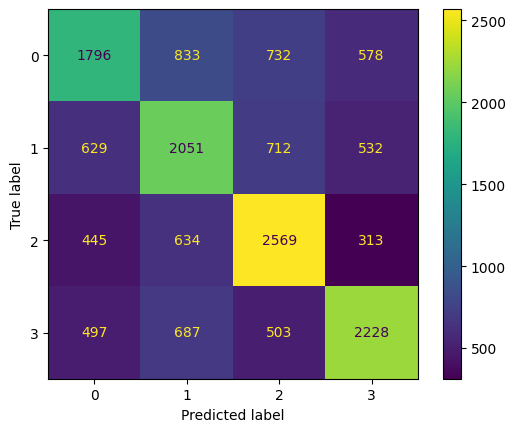

In [31]:
acc, y_true_train, y_pred = evaluate_model(clf, train_ds)
cm = confusion_matrix(y_true_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(num_classes)))
disp.plot() # will appear at the end of the output
print(classification_report(y_true_train, y_pred))

# Test Predictions

🧠 Test Accuracy: 0.5215
              precision    recall  f1-score   support

           0       0.48      0.40      0.44       862
           1       0.47      0.51      0.49       859
           2       0.55      0.60      0.58       866
           3       0.58      0.57      0.57       857

    accuracy                           0.52      3444
   macro avg       0.52      0.52      0.52      3444
weighted avg       0.52      0.52      0.52      3444



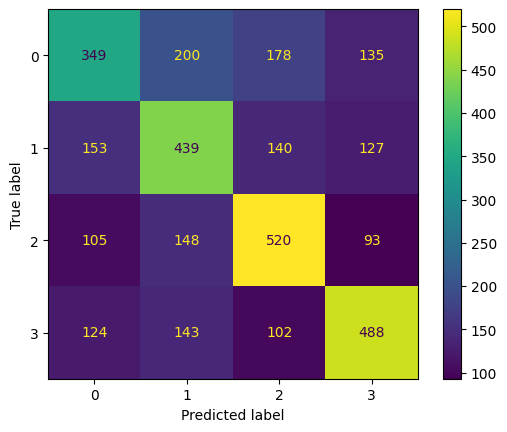

In [32]:
acc, y_true, y_pred = evaluate_model(clf, test_ds)
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(num_classes)))
disp.plot() # will appear at the end of the output
print(classification_report(y_true, y_pred))